In [1]:
# ============================================================
# FIRST RUN ONLY
#
# This cell:
#   1) loads the trace data needed to reproduce combined_idx_1000 / combined_idx_4000
#   2) loads the ripple spectrogram features
#   3) computes UMAP ONCE
#   4) builds ONLY the last three Figure 3D heatmaps:
#        - Ripple
#        - IED
#        - Neither
#   5) saves ONLY the final plotting data to a small cache
#
# After the cache is created once, do NOT run this cell again
# just to reproduce the plots.
# ============================================================

import os
import glob
import collections
import numpy as np
import matplotlib.pyplot as plt
import h5py

from scipy.io import loadmat
import umap.umap_ as umap

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def load_rdata_field(f, field):
    """Load a field like 'ripples' or 'Rspikes' from q/Rdata robustly."""
    path = f['q']['Rdata'][field]
    data = np.array(path)

    results = []
    if data.dtype == object:  # multiple blocks
        for ref in data.flatten():
            if isinstance(ref, h5py.Reference):
                results.append(np.array(f[ref]))
    else:  # single dataset
        results.append(data)

    return results


def sample_indices_only(all_traces, n_samples=1000, seed=42):
    """Return only the sampled indices for reproducibility."""
    rng = np.random.default_rng(seed)
    n_total = all_traces.shape[0]
    if n_total < n_samples:
        raise ValueError(f"Not enough traces: have {n_total}, need {n_samples}.")
    idx = rng.choice(n_total, size=n_samples, replace=False)
    return idx


def build_fraction_grid(embedding, combined_idx_1000, combined_idx_4000, positive_idx_5000):
    """
    Build the grid fraction heatmap used by the last three Figure 3D plots.

    Denominator:
        all sampled points in combined_idx_1000 U combined_idx_4000

    Numerator:
        points whose two-manual-label consensus belongs to the requested class
        (Ripple / IED / Neither)
    """
    min_vals = np.min(embedding, axis=0)
    max_vals = np.max(embedding, axis=0)

    grid_size = (20, 20)
    x_bins = np.linspace(min_vals[0], max_vals[0], grid_size[0] + 1)
    y_bins = np.linspace(min_vals[1], max_vals[1], grid_size[1] + 1)

    # Split the 5000-label vector into the first sampled 1000 and the later sampled 4000.
    split_pos = np.where(positive_idx_5000 >= 1000)[0][0]
    selected_1000 = combined_idx_1000[positive_idx_5000[:split_pos]]
    selected_4000 = combined_idx_4000[positive_idx_5000[split_pos:] - 1000]

    sampled_all = set(np.concatenate([combined_idx_1000, combined_idx_4000]).tolist())
    selected_all = set(np.concatenate([selected_1000, selected_4000]).tolist())

    grid_total = collections.defaultdict(int)
    grid_positive = collections.defaultdict(int)

    # denominator
    for i, (x, y) in enumerate(embedding):
        if i not in sampled_all:
            continue
        x_idx = np.searchsorted(x_bins, x) - 1
        y_idx = np.searchsorted(y_bins, y) - 1
        if 0 <= x_idx < grid_size[0] and 0 <= y_idx < grid_size[1]:
            grid_total[(x_idx, y_idx)] += 1

    # numerator
    for i, (x, y) in enumerate(embedding):
        if i not in selected_all:
            continue
        x_idx = np.searchsorted(x_bins, x) - 1
        y_idx = np.searchsorted(y_bins, y) - 1
        if 0 <= x_idx < grid_size[0] and 0 <= y_idx < grid_size[1]:
            grid_positive[(x_idx, y_idx)] += 1

    value = np.zeros(grid_size, dtype=float)
    val_min = float("inf")
    val_max = -float("inf")

    for i in range(grid_size[0]):
        for j in range(grid_size[1]):
            if (i, j) not in grid_total or grid_total[(i, j)] == 0:
                value[i, j] = np.nan
            else:
                frac = grid_positive[(i, j)] / grid_total[(i, j)]
                value[i, j] = frac
                val_min = min(val_min, frac)
                val_max = max(val_max, frac)

    return value, min_vals, max_vals, val_min, val_max


# ------------------------------------------------------------
# Shared configuration
# ------------------------------------------------------------
pt_ch_mapping = {
    "EC130_200": [1, 13],
    "EC133_200": [282, 291, 292, 293],
    "EC135_200": [303],
    "EC137_200": [257, 258, 259, 269],
    "EC143_200": [339],
    "EC157_200": [321, 332, 333, 334],
    "EC162_200": [85, 86],
    "EC175_200": [301, 302],
    "EC183_200": [290],
    "EC186_200": [299, 300, 301],
    "EC187_200": [309, 310],
    "EC191_200": [2, 3, 4],
    "EC196_200": [300, 301, 303],
    "EC219_200": [399, 400, 402, 403],
    "EC220_200": [53, 54, 76, 77],
    "EC221_200": [376, 377],
    "EC222_200": [267, 268, 269, 270],
}

pathname = '/scratch/dazhang/MATLAB/'

empty_blocks = {
    "EC133_ch282": {'B67'},
    "EC137_ch259": {'B176'},
    "EC183_ch290": {'B132', 'B139', 'B142'},
    # The followings are bad channels
    "EC220_ch55": {'B24', 'B27'},
    "EC220_ch75": {'B24', 'B27'},
    "EC221_ch375": {'B36', 'B47'},
    "EC221_ch374": {'B36', 'B47'},
    "EC196_ch302": {'B21'},
    "EC183_ch289": {'B132', 'B139', 'B142', 'B164'},
    "EC175_ch303": {'B11'},
    "EC157_ch322": {'B46'},
    "EC143_ch330": {'B35'},
    "EC137_ch260": {'B158', 'B185'},
    "EC137_ch259": {'B176'},
    "EC133_ch294": {'B60', 'B67'},
    "EC133_ch281": {'B60', 'B67'},
    "EC130_ch2": {'B8'},
}

# ------------------------------------------------------------
# Step 1: reproduce patient_block_map
# ------------------------------------------------------------
patient_block_map = collections.defaultdict(list)

for patient, channal_list in pt_ch_mapping.items():
    path = pathname + patient + '/'
    pt = patient[:-4]
    for cur_channel in channal_list:
        cur_channel = str(cur_channel)
        file_path = "/data/an/transformed/RR_h_referential_wSPKS/" + pt + "/AN/" + pt + "_AN_ch" + cur_channel + "_wSPKS.mat"
        block_names = []
        with h5py.File(file_path, "r") as f:
            blocks_refs = f['q']['blocks'][:]
            for i in range(blocks_refs.shape[1]):
                ref = blocks_refs[0, i]
                dataset = f[ref][:]
                text = ''.join(chr(c) for c in dataset.flatten())
                block_names.append(text)
            patient_block_map[pt] = block_names
        break

print("patient_block_map ready")

# ------------------------------------------------------------
# Step 2: reproduce all_traces only to regenerate the sampled indices
# ------------------------------------------------------------
file_list = []
meta_file_list = []
start_end_list = []
all_labels = []
all_traces = np.empty((0, 513))
all_specs_for_trace_pass = np.empty((0, 60))  # kept only for alignment while loading

for pt, blocks in patient_block_map.items():
    channel_list = pt_ch_mapping[pt + '_200']
    path = pathname + pt + '_200' + '/'
    ls_specs = np.empty((0, 60))

    for each_channel in channel_list:
        file_path = "/data/an/transformed/RR_h_referential_wSPKS/" + pt + "/AN/" + pt + "_AN_ch" + str(each_channel) + "_wSPKS.mat"

        with h5py.File(file_path, "r") as f:
            ripple_blocks = load_rdata_field(f, 'Rtraces')
            spike_blocks = load_rdata_field(f, 'Rspikes_THISchannel')
            ripple_start_end = load_rdata_field(f, 'ripples')

            assert len(ripple_blocks) == len(spike_blocks) and len(ripple_start_end) == len(spike_blocks)

            for ripples, spikes, start_end, each_block_name in zip(
                ripple_blocks, spike_blocks, ripple_start_end, blocks
            ):
                if pt + '_ch' + str(each_channel) in empty_blocks and each_block_name in empty_blocks[pt + '_ch' + str(each_channel)]:
                    continue
                else:
                    created_file = 'ls_ripple_' + pt + '_Channel_' + str(each_channel) + '_binsize_10_Block_' + str(blocks.index(each_block_name) + 1)
                    meta_file = pt + "_ch" + str(each_channel) + "_" + each_block_name

                if "Channel_" + str(each_channel) + "_" in created_file and ("-empty" not in created_file):
                    specs = loadmat(path + created_file)['ls_ripple']
                    ls_specs = np.concatenate([ls_specs, specs], axis=0)

                ripples = np.atleast_2d(ripples)
                spikes = np.atleast_1d(spikes)
                ripples_timepoint = np.atleast_2d(start_end)

                if ripples.shape == (1, 2) and spikes.shape == (2,):
                    continue

                spikes_1d = spikes.reshape(-1)
                assert len(ripples.T) == len(spikes.T) and len(ripples_timepoint.T) == len(ripples.T)

                meta_file_list.extend([meta_file] * len(spikes.T))
                start_end_list.extend(ripples_timepoint.T)
                all_labels.extend(spikes.T)

                for j, (trace, label) in enumerate(zip(ripples.T, spikes_1d)):
                    cur_trace = ripples.T[j].reshape(1, 513)
                    all_traces = np.concatenate([all_traces, cur_trace], axis=0)

    all_specs_for_trace_pass = np.concatenate([all_specs_for_trace_pass, ls_specs], axis=0)

print("all_traces:", all_traces.shape)

# Recreate the exact sampled index sets used later
combined_idx_1000 = sample_indices_only(all_traces, n_samples=1000, seed=123)
combined_idx_4000 = np.concatenate([
    sample_indices_only(all_traces, n_samples=1000, seed=456),
    sample_indices_only(all_traces, n_samples=1000, seed=789),
    sample_indices_only(all_traces, n_samples=1000, seed=101112),
    sample_indices_only(all_traces, n_samples=1000, seed=131415),
], axis=0)

print("combined_idx_1000:", combined_idx_1000.shape)
print("combined_idx_4000:", combined_idx_4000.shape)

# ------------------------------------------------------------
# Step 3: load all ripple spectrogram features once and compute ONE UMAP
# ------------------------------------------------------------
all_specs_label = []
all_specs = np.empty((0, 60))
file_list_specs = []

for patient, channal_list in pt_ch_mapping.items():
    path = pathname + patient + '/'
    ls_specs = np.empty((0, 60))

    for cur_channel in channal_list:
        cur_channel = str(cur_channel)
        for filename in glob.glob(os.path.join(path, '*.mat')):
            if ("ls_ripple" not in filename) or ("binsize_1_" in filename):
                continue
            with open(os.path.join(os.getcwd(), filename), 'r') as f:
                if "Channel_" + str(cur_channel) + "_" in filename and ("-empty" not in filename):
                    specs = loadmat(filename)['ls_ripple']
                    file_list_specs.append(filename)
                    ls_specs = np.concatenate([ls_specs, specs], axis=0)

    all_specs_label = np.concatenate([all_specs_label, [patient] * len(ls_specs)])
    all_specs = np.concatenate([all_specs, ls_specs], axis=0)

print("all_specs:", all_specs.shape)

all_vectors = np.asarray(all_specs)

embedding = umap.UMAP(
    n_components=2,
    min_dist=0.2,
    metric='euclidean',
    n_neighbors=15,
    random_state=42,
    n_epochs=100,
    verbose=True
).fit_transform(all_vectors)

print("embedding:", embedding.shape)

# ------------------------------------------------------------
# Step 4: consensus label indices from the 50-label files
# ------------------------------------------------------------
label_Da = loadmat('labels_final_Da_50.mat')['labels_all']
label_Jon = loadmat('labels_final_Jon_50.mat')['labels_all']

labels_Jon = [x.item() for x in label_Jon.flatten()]
labels_Da = [x.item() for x in label_Da.flatten()]

both_ripple = (np.array(labels_Jon) == "Ripple") & (np.array(labels_Da) == "Ripple")
both_ied = (np.array(labels_Jon) == "IED") & (np.array(labels_Da) == "IED")
both_neither = (np.array(labels_Jon) == "Neither") & (np.array(labels_Da) == "Neither")

ripple_idx_both_50 = np.where(both_ripple)[0]
ied_idx_both_50 = np.where(both_ied)[0]
neither_idx_both_50 = np.where(both_neither)[0]

print("ripple consensus count:", len(ripple_idx_both_50))
print("IED consensus count:", len(ied_idx_both_50))
print("Neither consensus count:", len(neither_idx_both_50))

# ------------------------------------------------------------
# Step 5: build ONLY the final three heatmaps
# ------------------------------------------------------------
ripple_grid, min_vals, max_vals, ripple_vmin, ripple_vmax = build_fraction_grid(
    embedding, combined_idx_1000, combined_idx_4000, ripple_idx_both_50
)

ied_grid, _, _, ied_vmin, ied_vmax = build_fraction_grid(
    embedding, combined_idx_1000, combined_idx_4000, ied_idx_both_50
)

neither_grid, _, _, neither_vmin, neither_vmax = build_fraction_grid(
    embedding, combined_idx_1000, combined_idx_4000, neither_idx_both_50
)

print("Ripple range:", ripple_vmin, ripple_vmax)
print("IED range:", ied_vmin, ied_vmax)
print("Neither range:", neither_vmin, neither_vmax)

# ------------------------------------------------------------
# Step 6: save ONLY the final plotting data
# ------------------------------------------------------------
CACHE_FILE = "Figure3_D_last3_plot_inputs.npz"
TMP_FILE = "Figure3_D_last3_plot_inputs.tmp.npz"

if os.path.exists(TMP_FILE):
    os.remove(TMP_FILE)

np.savez(
    TMP_FILE,
    min_vals=min_vals,
    max_vals=max_vals,
    ripple_grid=ripple_grid,
    ripple_vmin=np.asarray(ripple_vmin),
    ripple_vmax=np.asarray(ripple_vmax),
    ied_grid=ied_grid,
    ied_vmin=np.asarray(ied_vmin),
    ied_vmax=np.asarray(ied_vmax),
    neither_grid=neither_grid,
    neither_vmin=np.asarray(neither_vmin),
    neither_vmax=np.asarray(neither_vmax),
)

with np.load(TMP_FILE, allow_pickle=False) as _check:
    _ = _check["min_vals"]
    _ = _check["max_vals"]
    _ = _check["ripple_grid"]
    _ = _check["ied_grid"]
    _ = _check["neither_grid"]

os.replace(TMP_FILE, CACHE_FILE)

print(f"Saved and verified: {CACHE_FILE}")
print("Future reproduction: skip this first-run cell and use only the plot-only cells below.")


patient_block_map ready
all_traces: (31847, 513)
combined_idx_1000: (1000,)
combined_idx_4000: (4000,)
all_specs: (31847, 60)
UMAP(min_dist=0.2, n_epochs=100, n_jobs=1, random_state=42, verbose=True)
Sat Sep 19 00:36:56 2026 Construct fuzzy simplicial set
Sat Sep 19 00:36:56 2026 Finding Nearest Neighbors
Sat Sep 19 00:36:56 2026 Building RP forest with 14 trees


/home/dazhang/anaconda3/envs/klab/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Sat Sep 19 00:36:59 2026 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	 3  /  15
	 4  /  15
	Stopping threshold met -- exiting after 4 iterations
Sat Sep 19 00:37:12 2026 Finished Nearest Neighbor Search
Sat Sep 19 00:37:14 2026 Construct embedding


Epochs completed:   0%|            0/100 [00:00]

	completed  0  /  100 epochs
	completed  10  /  100 epochs
	completed  20  /  100 epochs
	completed  30  /  100 epochs
	completed  40  /  100 epochs
	completed  50  /  100 epochs
	completed  60  /  100 epochs
	completed  70  /  100 epochs
	completed  80  /  100 epochs
	completed  90  /  100 epochs
Sat Sep 19 00:37:20 2026 Finished embedding
embedding: (31847, 2)
ripple consensus count: 3734
IED consensus count: 582
Neither consensus count: 469
Ripple range: 0.0 1.0
IED range: 0.0 1.0
Neither range: 0.0 0.5714285714285714
Saved and verified: Figure3_D_last3_plot_inputs.npz
Future reproduction: skip this first-run cell and use only the plot-only cells below.


In [2]:
# ============================================================
# PLOT ONLY LOADER — START HERE FOR ALL FUTURE REPRODUCTION
#
# No raw-data loading
# No sampling regeneration
# No UMAP
# No fitting
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

CACHE_FILE = "Figure3_D_last3_plot_inputs.npz"

with np.load(CACHE_FILE, allow_pickle=False) as cached:
    min_vals = cached["min_vals"]
    max_vals = cached["max_vals"]

    ripple_grid = cached["ripple_grid"]
    ripple_vmin = float(cached["ripple_vmin"])
    ripple_vmax = float(cached["ripple_vmax"])

    ied_grid = cached["ied_grid"]
    ied_vmin = float(cached["ied_vmin"])
    ied_vmax = float(cached["ied_vmax"])

    neither_grid = cached["neither_grid"]
    neither_vmin = float(cached["neither_vmin"])
    neither_vmax = float(cached["neither_vmax"])

print(f"Loaded: {CACHE_FILE}")
print("Plotting only — no UMAP or recomputation is being run.")

plasma = plt.cm.get_cmap("plasma")


Loaded: Figure3_D_last3_plot_inputs.npz
Plotting only — no UMAP or recomputation is being run.


/tmp/ipykernel_2588540/15248497.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plasma = plt.cm.get_cmap("plasma")


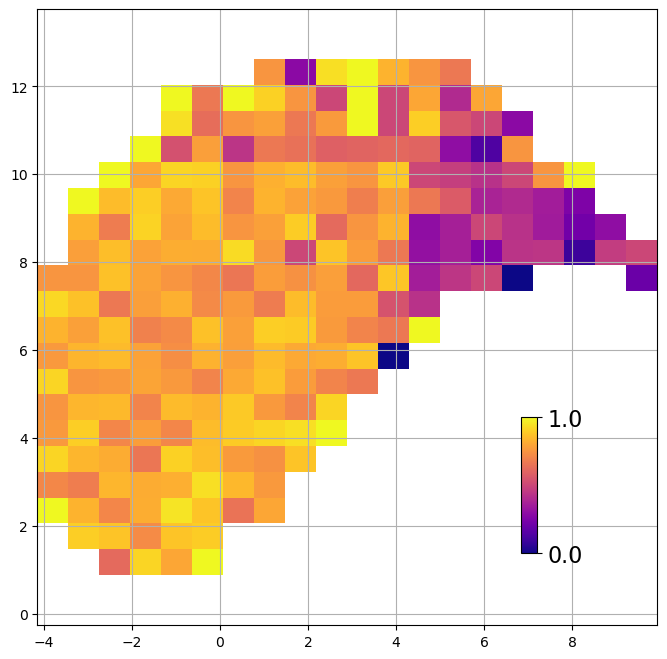

In [3]:
# Ripple heatmap — PLOT ONLY
fig, ax = plt.subplots(figsize=(8, 8))
ax.grid(True)
ax.axis("equal")
ax.set_facecolor("white")

masked_data = np.ma.masked_invalid(ripple_grid.T)

c2 = ax.imshow(
    masked_data,
    origin="lower",
    cmap=plasma,
    extent=[min_vals[0], max_vals[0], min_vals[1], max_vals[1]],
)

c2.set_clim(ripple_vmin, ripple_vmax)

cax = fig.add_axes([0.73, 0.20, 0.02, 0.17])
cbar = plt.colorbar(c2, cax=cax, orientation="vertical")
cbar.ax.tick_params(labelsize=16)
cbar.set_ticks([ripple_vmin, ripple_vmax])
cbar.set_ticklabels([f"{ripple_vmin:.1f}", f"{ripple_vmax}"])

plt.show()


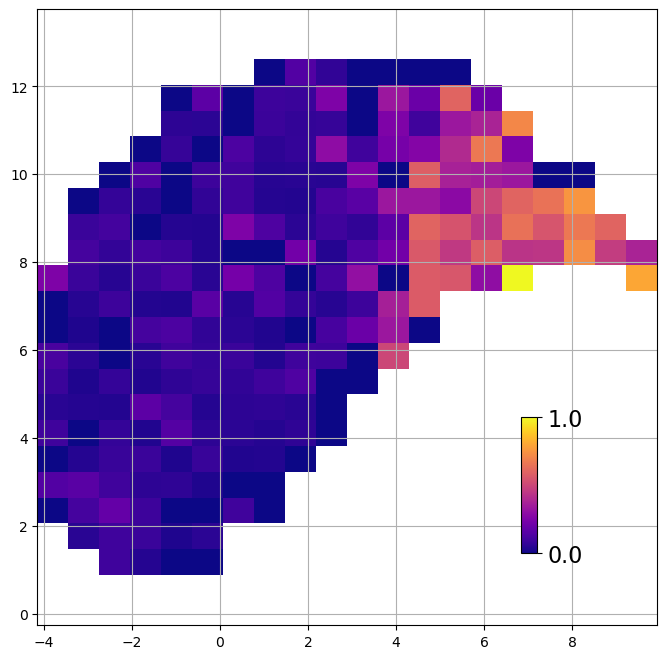

In [4]:
# IED heatmap — PLOT ONLY
fig, ax = plt.subplots(figsize=(8, 8))
ax.grid(True)
ax.axis("equal")
ax.set_facecolor("white")

masked_data = np.ma.masked_invalid(ied_grid.T)

c2 = ax.imshow(
    masked_data,
    origin="lower",
    cmap=plasma,
    extent=[min_vals[0], max_vals[0], min_vals[1], max_vals[1]],
)

c2.set_clim(ied_vmin, ied_vmax)

cax = fig.add_axes([0.73, 0.20, 0.02, 0.17])
cbar = plt.colorbar(c2, cax=cax, orientation="vertical")
cbar.ax.tick_params(labelsize=16)
cbar.set_ticks([ied_vmin, ied_vmax])
cbar.set_ticklabels([f"{ied_vmin:.1f}", f"{ied_vmax}"])

plt.show()


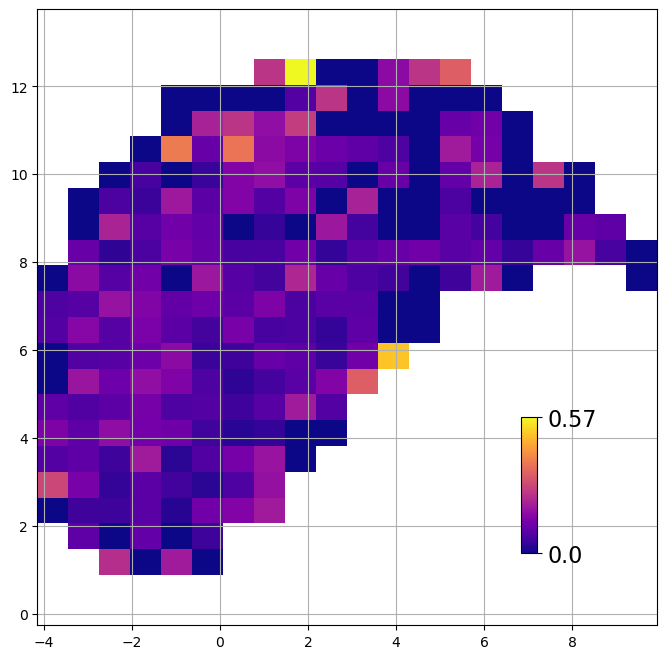

In [5]:
# Neither heatmap — PLOT ONLY
fig, ax = plt.subplots(figsize=(8, 8))
ax.grid(True)
ax.axis("equal")
ax.set_facecolor("white")

masked_data = np.ma.masked_invalid(neither_grid.T)

c2 = ax.imshow(
    masked_data,
    origin="lower",
    cmap=plasma,
    extent=[min_vals[0], max_vals[0], min_vals[1], max_vals[1]],
)

c2.set_clim(neither_vmin, neither_vmax)

cax = fig.add_axes([0.73, 0.20, 0.02, 0.17])
cbar = plt.colorbar(c2, cax=cax, orientation="vertical")
cbar.ax.tick_params(labelsize=16)
cbar.set_ticks([neither_vmin, neither_vmax])
cbar.set_ticklabels([f"{neither_vmin:.1f}", f"{neither_vmax:.2f}"])

plt.show()
